# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (v5.0)
- **8 agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender
- **Soft agent cycling**: all agents learn every episode (non-active at reduced LR)

## 1. Setup — Clone Repository & Install Dependencies

In [2]:
import os, sys

def _is_project_root(path: str) -> bool:
    """A valid project root has both src/ and configs/ directories."""
    return (os.path.isdir(os.path.join(path, 'src')) and
            os.path.isdir(os.path.join(path, 'configs')))

if not _is_project_root('.'):
    # ── Local: notebook is inside notebooks/ → project root is one level up ──
    _local_candidates = ['..', os.path.join('..', '..')]

    # ── Colab: after git clone the repo lands next to this notebook ──────────
    _colab_candidates = [
        os.path.join('Thesis-Energy-Auction', 'ets_marl ppo'),   # space (GitHub name)
        os.path.join('Thesis-Energy-Auction', 'ets_marl_ppo'),   # underscore variant
        'Thesis-Energy-Auction',
    ]

    _found = False
    for _c in _local_candidates + _colab_candidates:
        if _is_project_root(_c):
            os.chdir(_c)
            _found = True
            break

    if not _found:
        # Must be Colab with no clone yet — clone then retry
        os.system('git clone https://github.com/DJH961/Thesis-Energy-Auction.git 2>/dev/null || echo "Repo already cloned"')
        for _c in _colab_candidates:
            if _is_project_root(_c):
                os.chdir(_c)
                _found = True
                break

    if not _found:
        raise FileNotFoundError(
            f'Cannot find project root (needs src/ + configs/).\n'
            f'CWD: {os.getcwd()}  |  Contents: {os.listdir(".")}'
        )

sys.path.insert(0, '.')
print(f'Working directory: {os.getcwd()}')


Working directory: c:\Users\t-dhenke\OneDrive - Microsoft\Documents\VS Code\Master Thesis Code\Thesis-Energy-Auction\ets_marl_happo_current


In [3]:
# Install dependencies
!pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [4]:
!python -m pytest tests/ -v

============================= test session starts =============================
platform win32 -- Python 3.13.12, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\t-dhenke\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\t-dhenke\OneDrive - Microsoft\Documents\VS Code\Master Thesis Code\Thesis-Energy-Auction\ets_marl_happo_current
configfile: pyproject.toml
plugins: anyio-4.10.0
collecting ... collected 145 items

tests/test_anchors.py::TestAuctionAnchors::test_anchored_price_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_qty_near_target PASSED [  1%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_invest_frac PASSED [  2%]
tests/test_anchors.py::TestAuctionAnchors::test_no_anchors_gives_midpoint PASSED [  2%]
tests/test_anchors.py::TestAuctionAnchors::test_anchors_within_bounds PASSED [  3%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_price_mult 

## 3. Explore the Environment

In [5]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {TECH_NAMES}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

tech_names = config['technologies']['names']
for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(5)])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')

=== Environment Summary ===
Agents: 8
Years: 20
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 57
Initial cap: 23.50 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A3: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A4: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A5: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A6: coal: 5% | gas: 25% | o

## 4. Run a Random-Policy Episode (Baseline)

In [7]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config['auction']
inv = config['investment']

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions (use config bounds)
    auction_actions = rng.uniform(
        [aq['price_min'], 0.0, 0.0, -1.0, -1.0, -1.0],
        [aq['price_max'], aq['quantity_max'], inv['max_invest_frac'], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions
    secondary_actions = rng.uniform(
        [0.5, -aq['quantity_max']], [2.0, aq['quantity_max']], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'reward_A{i+1}'] = rewards[i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[['year', 'cap', 'price']].to_string(index=False))

 year       cap      price
    0 23.500000 381.764160
    1 22.489500 150.328903
    2 21.522451 169.126648
    3 20.596986 186.991928
    4 19.690719 158.615662
    5 18.824327 403.173950
    6 17.996057 199.675079
    7 17.204230 203.057251
    8 16.447244 264.918701
    9 15.723565 241.365402
   10 15.031728 297.208527
   11 14.370332 497.377380
   12 13.738038 276.253693
   13 13.133564 361.059692
   14 12.555687 448.580444
   15 12.003237 313.240814
   16 11.475095 329.481293
   17 10.970190 295.050873
   18 10.487502 250.072800
   19 10.026052 233.227997


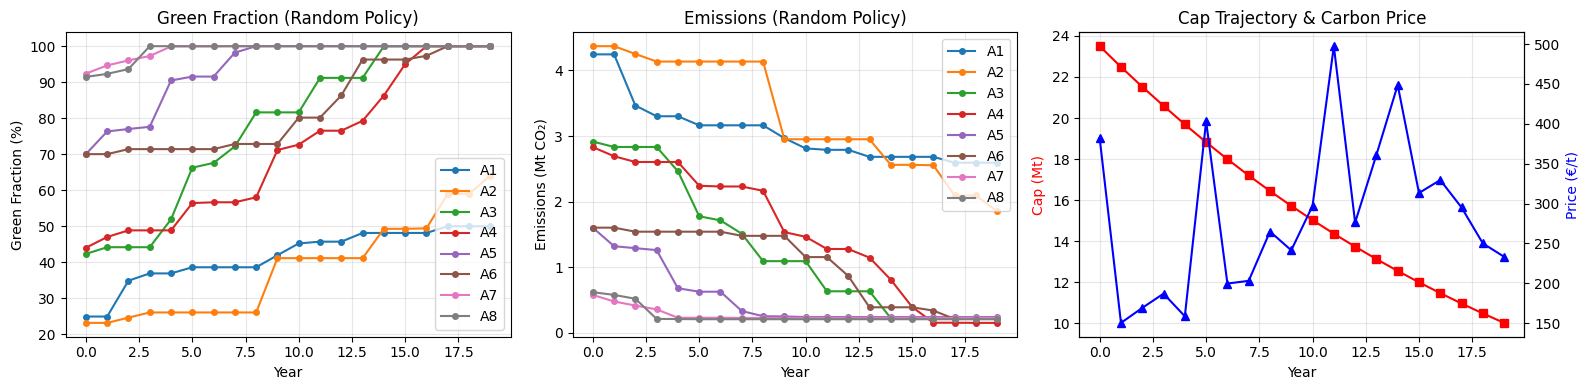

In [8]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [9]:
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = config.copy()
train_config['simulation'] = dict(config['simulation'])
train_config['simulation']['n_episodes'] = 1500  # Increase for better results
train_config['logging'] = dict(config['logging'])
train_config['logging']['log_interval'] = 49
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)


Training — seed 42, 8 agents, HAPPO (sequential update, centralized critic), two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward | CF-cap=0.5×
Clipped Gaussian (no tanh) + P1-P8 active | Curriculum 4→20yr | ε-greedy 25%→5%

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    :

## 6. Analyze Training Results

In [10]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 1500
Year-level records: 11996


episode  clearing_price_last   cap_last  entropy_coef  shaping_weight  \
1495     1495            38.520100  14.370332          0.03          0.8754   
1496     1496            21.879153  14.370332          0.03          0.8753   
1497     1497           136.132477  14.370332          0.03          0.8752   
1498     1498            42.487743  14.370332          0.03          0.8752   
1499     1499            29.331257  14.370332          0.03          0.8751   

      entropy_decay_triggered  active_agent  epsilon  reward_A1  \
1495                        1            -1   0.2073   -36.9471   
1496                        1            -1   0.2073   -30.8472   
1497                        1            -1   0.2072   -45.2262   
1498                        1            -1   0.2072    -0.3747   
1499                        1            -1   0.2072   -47.1102   

1495         0.2892  ...                 0                    0.0   
1496         0.4378  ...                 0                    0.0   
1497         0.2466  ...                 0                    0.0   
1498         0.4974  ...                 0                    0.0   
1499         0.3703  ...                 0                    0.0   

      total_mac_reduction_A7  mean_alloc_A8  mean_shock_A8  max_shock_A8  \
1495                     0.0         0.1145            0.0           0.0   
1496                     0.0         0.1797            0.0           0.0   
1497                     0.0         0.2780            0.0           0.0   
1498                     0.0         0.2051            0.0           0.0   
1499                     0.0         0.1800            0.0           0.0   

1495               0.0                 0                    0.0   
1496               0.0                 0                    0.0   
1497               0.0                 0                    0.0   
1498               0.0                 0                    0.0   
1499               0.0                 0                    0.0   

      total_mac_reduction_A8  
1495                     0.0  
1496                     0.0  
1497                     0.0  
1498                     0.0  
1499                     0.0  

[5 rows x 142 columns]

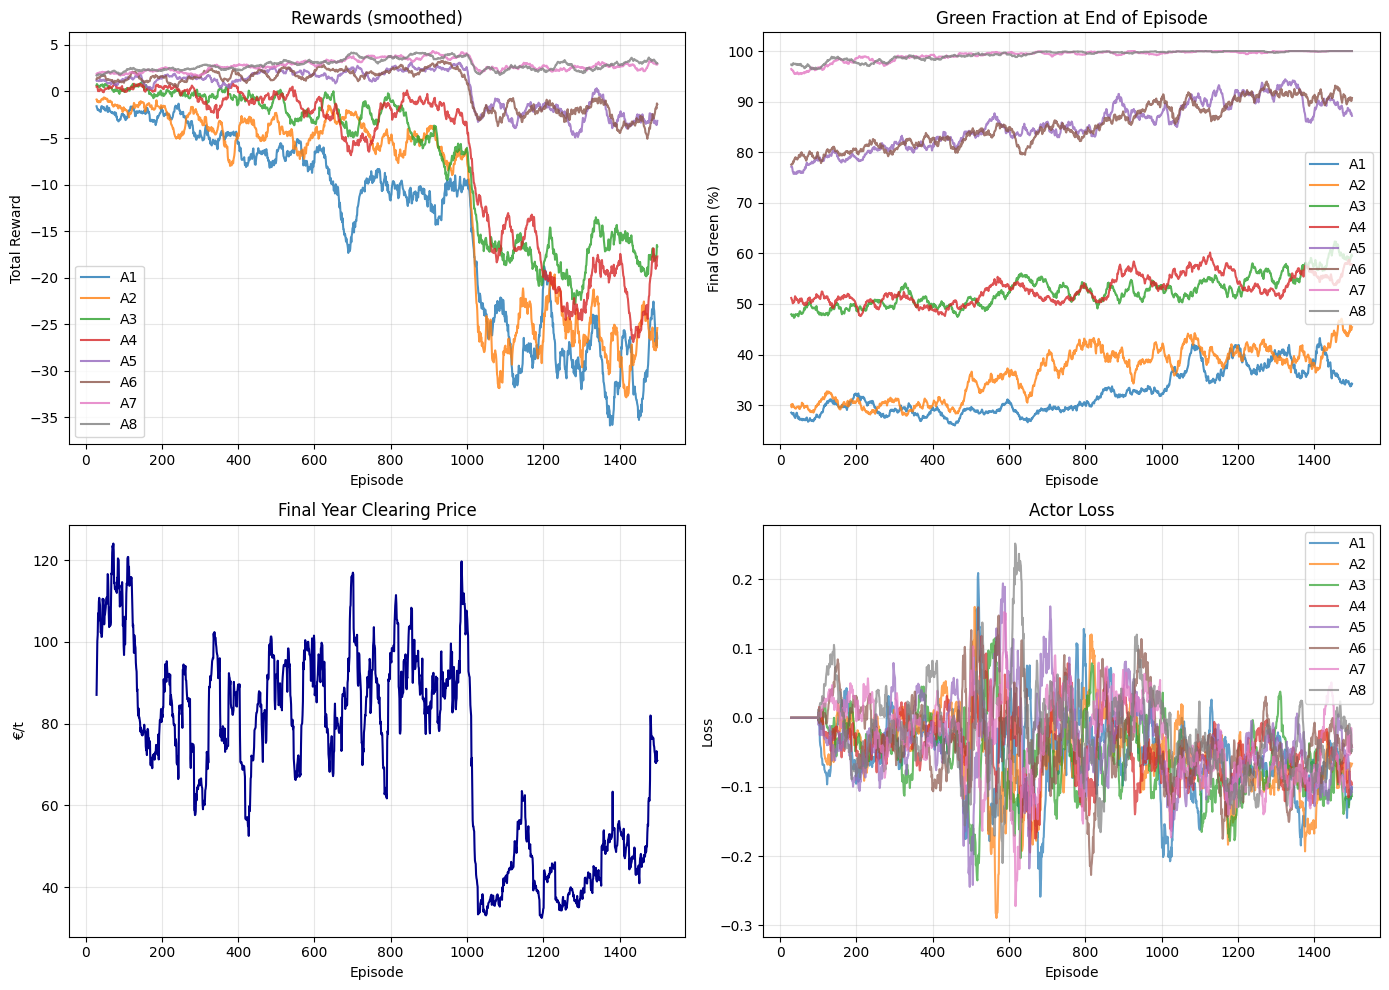

In [11]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

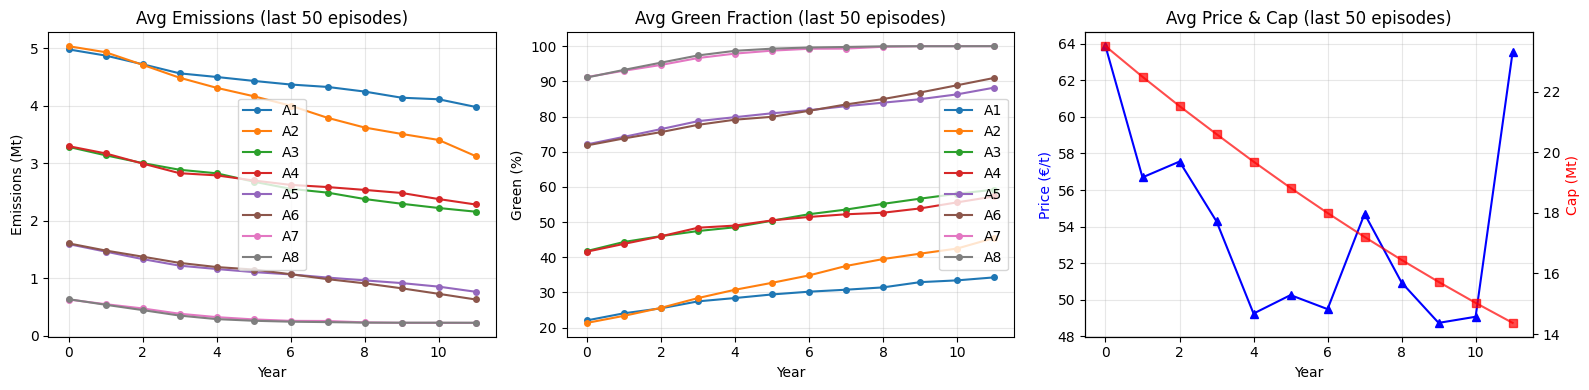

In [12]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6b. P5–P6 & MAC Stochastic Deviation Analysis

Visualise the **random noise** and **abatement mechanisms** across training:
- **P5** — Emission demand shocks (ε ~ correlated normal, σ=7%)
- **P6** — Green capacity-factor noise + project cancellations
- **MAC** — Fuel-switching abatement (coal→gas dispatch when carbon price > €65/t)

In [20]:
# ── P5/P6 stochastic deviation analysis (adaptive) ─────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

# Column groups
shock_cols  = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols     = [f'cf_shock_A{i+1}' for i in range(n_agents)]
cancel_cols = [f'cancellation_A{i+1}' for i in range(n_agents)]
mac_cols    = [f'mac_reduction_A{i+1}' for i in range(n_agents)]


def cols_exist(cols):
    return all(c in yr_df.columns for c in cols)


def has_signal(cols, eps=1e-12):
    if not cols_exist(cols):
        return False
    vals = yr_df[cols].to_numpy(dtype=float)
    return np.nanstd(vals) > eps


def has_positive_mass(cols, eps=1e-12):
    if not cols_exist(cols):
        return False
    vals = yr_df[cols].to_numpy(dtype=float)
    return np.nansum(np.abs(vals)) > eps


has_p5 = has_signal(shock_cols)
has_p6_cf = has_signal(cf_cols)
has_p6_cancel = has_positive_mass(cancel_cols)
has_mac = has_positive_mass(mac_cols)

# Recent episodes for cleaner trend diagnostics
n_unique_eps = yr_df['episode'].nunique()
N_LAST = min(300, n_unique_eps)
recent_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(recent_eps)].copy()

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i % 10) for i in range(n_agents)]
leg_ncol = max(1, n_agents // 4)
bar_alpha = max(0.25, 0.55 - n_agents * 0.03)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 1) P5 shock distribution OR fallback: emissions variability ─────────────────
ax = axes[0, 0]
if has_p5:
    for i in range(n_agents):
        vals = yr_df[shock_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}', density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Emission shock ε (%)')
    ax.set_ylabel('Density')
    ax.set_title('P5 — Emission Demand Shocks\n(all years & episodes)')
    ax.legend(fontsize=7, ncol=leg_ncol)
else:
    for i in range(n_agents):
        s = recent.groupby('episode')[f'emissions_A{i+1}'].std().rolling(30, min_periods=1).mean()
        ax.plot(s.index, s.values, lw=1.2, alpha=0.85, label=f'A{i+1}', color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Within-episode emissions std (Mt)')
    ax.set_title('Fallback — Emissions Variability over Training\n(P5 shock appears inactive)')
    ax.legend(fontsize=7, ncol=leg_ncol)
ax.grid(True, alpha=0.3)

# ── 2) P5 cross-agent correlation OR fallback: clearing price distribution ──────
ax = axes[0, 1]
if has_p5:
    idx_a, idx_b = 0, max(1, n_agents // 2)
    ax.scatter(
        yr_df[shock_cols[idx_a]] * 100,
        yr_df[shock_cols[idx_b]] * 100,
        alpha=0.15,
        s=4,
        color='steelblue'
    )
    lims = [-25, 25]
    ax.plot(lims, lims, 'k--', lw=0.8, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    corr = yr_df[shock_cols[idx_a]].corr(yr_df[shock_cols[idx_b]])
    ax.set_xlabel(f'A{idx_a+1} shock (%)')
    ax.set_ylabel(f'A{idx_b+1} shock (%)')
    ax.set_title(f'P5 — Cross-Agent Shock Correlation\nA{idx_a+1} vs A{idx_b+1}  (ρ_obs = {corr:.2f})')
    ax.legend(fontsize=8)
else:
    cp = recent['clearing_price']
    ax.hist(cp, bins=40, density=True, alpha=0.7, color='steelblue')
    ax.axvline(cp.mean(), color='k', lw=1, ls='--', label=f'mean={cp.mean():.1f}')
    ax.set_xlabel('Clearing price (€/t)')
    ax.set_ylabel('Density')
    ax.set_title('Fallback — Clearing Price Distribution\n(last episodes)')
    ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 3) MAC trend OR fallback: price+cap trend ───────────────────────────────────
ax = axes[0, 2]
if has_mac:
    ep_mac = (
        yr_df.groupby('episode')[mac_cols]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    for i in range(n_agents):
        ax.plot(ep_mac.index, ep_mac[mac_cols[i]], label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('MAC abatement / episode (Mt)')
    ax.set_title('MAC Fuel-Switching over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=7, ncol=leg_ncol)
else:
    ep = recent.groupby('episode')[['clearing_price', 'cap']].mean().rolling(30, min_periods=1).mean()
    ax.plot(ep.index, ep['clearing_price'], color='steelblue', label='Price (€/t)')
    ax2 = ax.twinx()
    ax2.plot(ep.index, ep['cap'], color='darkred', label='Cap (Mt)', alpha=0.8)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Price (€/t)', color='steelblue')
    ax2.set_ylabel('Cap (Mt)', color='darkred')
    ax.set_title('Fallback — Price and Cap Trends\n(last episodes)')
ax.grid(True, alpha=0.3)

# ── 4) P6 CF-noise distribution OR fallback: green trajectory ───────────────────
ax = axes[1, 0]
if has_p6_cf:
    for i in range(n_agents):
        vals = yr_df[cf_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}', density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mean green CF noise (%)')
    ax.set_ylabel('Density')
    ax.set_title('P6 — Capacity-Factor Noise\n(mean across onshore/offshore/solar)')
    ax.legend(fontsize=7, ncol=leg_ncol)
else:
    for i in range(n_agents):
        g = recent.groupby('year')[f'green_frac_A{i+1}'].mean() * 100
        ax.plot(g.index, g.values, lw=1.8, alpha=0.9, label=f'A{i+1}', color=agent_colors[i])
    ax.set_xlabel('Year in episode')
    ax.set_ylabel('Green share (%)')
    ax.set_title('Fallback — Green Fraction Trajectory\n(P6 CF-noise appears inactive)')
    ax.legend(fontsize=7, ncol=leg_ncol)
ax.grid(True, alpha=0.3)

# ── 5) P6 cancellations OR fallback: shortfall trend ────────────────────────────
ax = axes[1, 1]
if has_p6_cancel:
    ep_cancels = (
        yr_df.groupby('episode')[cancel_cols]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    ep_cancels['total'] = ep_cancels[cancel_cols].sum(axis=1)
    ax.fill_between(ep_cancels.index, ep_cancels['total'], alpha=0.3, color='coral', label='Total (all agents)')
    for i in range(n_agents):
        ax.plot(ep_cancels.index, ep_cancels[cancel_cols[i]], lw=0.8, label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg cancellations / episode')
    ax.set_title('P6 — Project Cancellations over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=7, ncol=leg_ncol)
else:
    for i in range(n_agents):
        sf = recent.groupby('episode')[f'shortfall_A{i+1}'].mean().rolling(30, min_periods=1).mean()
        ax.plot(sf.index, sf.values, lw=1.2, alpha=0.85, label=f'A{i+1}', color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average shortfall (Mt)')
    ax.set_title('Fallback — Compliance Shortfall Trend\n(P6 cancellation appears inactive)')
    ax.legend(fontsize=7, ncol=leg_ncol)
ax.grid(True, alpha=0.3)

# ── 6) Banking dynamics ─────────────────────────────────────────────────────────
ax = axes[1, 2]
for i in range(n_agents):
    bs = recent.groupby('episode')[f'bank_start_A{i+1}'].mean().rolling(30, min_periods=1).mean()
    ax.plot(bs.index, bs.values, lw=1.2, alpha=0.85, label=f'A{i+1}', color=agent_colors[i])
ax.set_xlabel('Episode')
ax.set_ylabel('Bank start (Mt)')
ax.set_title('Banking Dynamics')
ax.legend(fontsize=7, ncol=leg_ncol)
ax.grid(True, alpha=0.3)

plt.suptitle('P5–P6 & MAC Diagnostics (Adaptive to Active Signals)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table + signal health
print('\n--- Active signal check ---')
print(f'P5 shock active:          {has_p5}')
print(f'P6 CF-noise active:       {has_p6_cf}')
print(f'P6 cancellation active:   {has_p6_cancel}')
print(f'MAC reduction active:     {has_mac}')

print('\n--- P5/P6/MAC summary (all data) ---')
summary = {}
for i in range(n_agents):
    row = {
        'eps_mean (%)': round(yr_df[shock_cols[i]].mean() * 100, 3) if cols_exist(shock_cols) else 'n/a',
        'eps_std (%)': round(yr_df[shock_cols[i]].std() * 100, 3) if cols_exist(shock_cols) else 'n/a',
        'cf_std (%)': round(yr_df[cf_cols[i]].std() * 100, 3) if cols_exist(cf_cols) else 'n/a',
        'cancels_total': int(yr_df[cancel_cols[i]].sum()) if cols_exist(cancel_cols) else 'n/a',
        'mac_total (Mt)': round(yr_df[mac_cols[i]].sum(), 2) if cols_exist(mac_cols) else 'n/a',
    }
    summary[f'A{i+1}'] = row

print(pd.DataFrame(summary).T.to_string())

## 6c. Year-by-Year Trajectory Analysis (last N episodes)

Slices the **year_log** to show how behaviour evolves *within* an episode across years 0–9.
Uses the last 100 episodes so the plots represent mature policy behaviour, not early exploration.

Four panels per row:
1. **Allocation vs Emissions** — over-allocation → surplus banking; under-allocation → shortfall risk  
2. **Banking** — bank_start and bank_end per year to see carry-forward dynamics  
3. **Secondary market net** — positive = net seller (revenue), negative = net buyer (cost)  
4. **Compliance surplus / shortfall** — pre-compliance headroom; negative → penalty risk

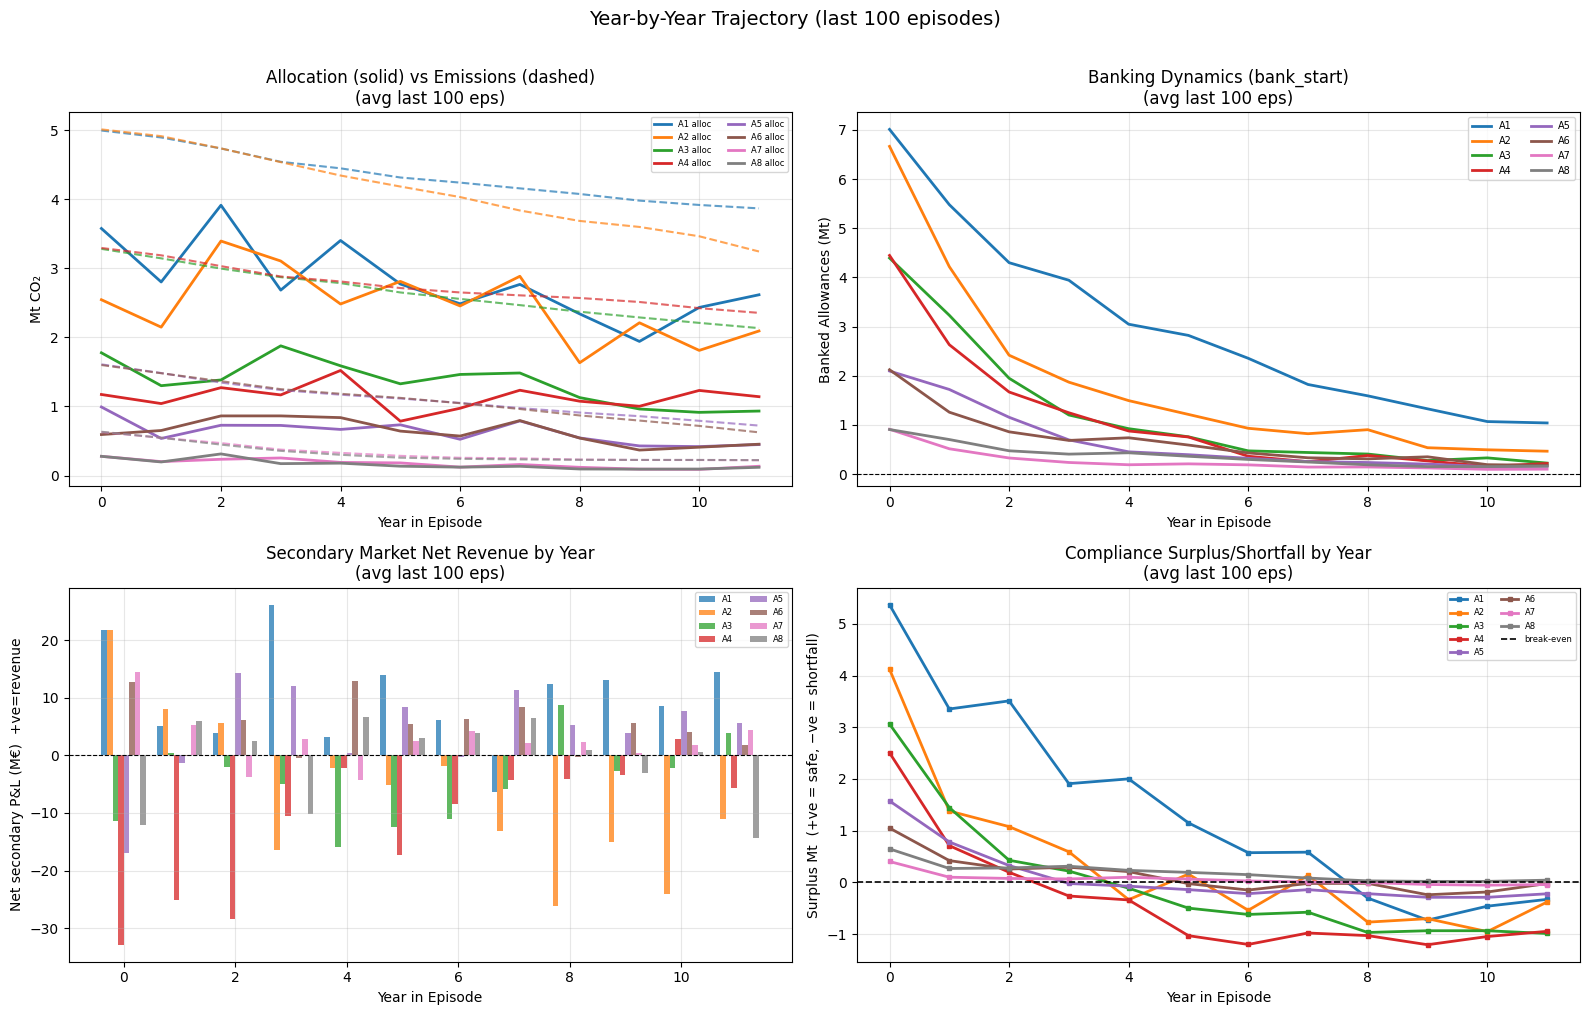


── Average yearly cost breakdown (last 100 eps, all agents combined) ──
      A1_auc(M€)  A1_inv(M€)  A1_pen(M€)  A2_auc(M€)  A2_inv(M€)  A2_pen(M€)  A3_auc(M€)  A3_inv(M€)  A3_pen(M€)  A4_auc(M€)  A4_inv(M€)  A4_pen(M€)  A5_auc(M€)  A5_inv(M€)  A5_pen(M€)  A6_auc(M€)  A6_inv(M€)  A6_pen(M€)  A7_auc(M€)  A7_inv(M€)  A7_pen(M€)  A8_auc(M€)  A8_inv(M€)  A8_pen(M€)
year                                                                                                                                                                                                                                                                                                
0         305.71      178.58       11.27      187.36      235.37        9.95      146.01      166.20       16.99       76.70      159.42       12.72       64.16      106.46       14.87       36.87      108.72       21.10       18.76      118.82       11.36       16.41      147.93        5.76
1         183.10      139.17      106.12      13

In [14]:
# ── 6c: Year-by-year trajectory analysis ──────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100  # episodes to average over
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()

# Check which new columns are present
has_bank_end   = 'bank_end_A1'            in recent.columns
has_sec_net    = 'secondary_net_A1'       in recent.columns
has_surplus    = 'compliance_surplus_A1'  in recent.columns
has_auc_cost   = 'auction_cost_A1'        in recent.columns

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Panel 1: Allocation vs Emissions ──────────────────────────────────────
ax = axes[0, 0]
for i in range(n_agents):
    alloc_avg = recent.groupby('year')[f'alloc_A{i+1}'].mean()
    emiss_avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(alloc_avg.index, alloc_avg.values,
            color=agent_colors[i], lw=2, label=f'A{i+1} alloc')
    ax.plot(emiss_avg.index, emiss_avg.values,
            color=agent_colors[i], lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Mt CO₂')
ax.set_title(f'Allocation (solid) vs Emissions (dashed)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: Banking dynamics (bank_start and bank_end) ────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    bs = recent.groupby('year')[f'bank_start_A{i+1}'].mean()
    ax.plot(bs.index, bs.values, color=agent_colors[i], lw=2,
            label=f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Banked Allowances (Mt)')
ax.set_title(f'Banking Dynamics (bank_start)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: Secondary market net (positive = net revenue) ────────────────
ax = axes[1, 0]
if has_sec_net:
    bar_width = 0.8 / n_agents
    for i in range(n_agents):
        avg = recent.groupby('year')[f'secondary_net_A{i+1}'].mean()
        ax.bar(avg.index + i * bar_width - 0.4 + bar_width/2, avg.values,
               width=bar_width, color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('Net secondary P&L (M€)  +ve=revenue')
    ax.set_title(f'Secondary Market Net Revenue by Year\n(avg last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
else:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'trade_cost_A{i+1}'].mean()
        ax.plot(avg.index, -avg.values, color=agent_colors[i], lw=1.5,
                label=f'A{i+1}', marker='o', markersize=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('−trade_cost (M€)  +ve=revenue')
    ax.set_title(f'Secondary Net (from trade_cost, last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 4: Compliance surplus / shortfall ───────────────────────────────
ax = axes[1, 1]
if has_surplus:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'compliance_surplus_A{i+1}'].mean()
        ax.plot(avg.index, avg.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='break-even')
else:
    for i in range(n_agents):
        sf = recent.groupby('year')[f'shortfall_A{i+1}'].mean()
        ax.plot(sf.index, -sf.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Surplus Mt  (+ve = safe, −ve = shortfall)')
ax.set_title(f'Compliance Surplus/Shortfall by Year\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Year-by-Year Trajectory (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost breakdown summary per year (if auction_cost logged) ──────────────
if has_auc_cost:
    print(f'\n── Average yearly cost breakdown (last {N_LAST} eps, all agents combined) ──')
    cols_show = {}
    for i in range(n_agents):
        cols_show[f'A{i+1}_auc(M€)'] = recent.groupby('year')[f'auction_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_inv(M€)'] = recent.groupby('year')[f'invest_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_pen(M€)'] = recent.groupby('year')[f'penalty_A{i+1}'].mean()
    print(pd.DataFrame(cols_show).round(2).to_string())


## 6d. Episode Consistency & Variance (ribbon plots)

Shows **mean ± 1 std** bands over the last 100 episodes for key year-level signals.
Wide bands → high variance / unstable policy. Narrow bands → consistent behaviour.

Includes a **price ribbon** (year 0→9 trajectory) and per-agent **green fraction trajectory**.

In [15]:
# ── 6d: Episode consistency – ribbon plots (mean ± 1σ over last 100 episodes) ──
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()
years  = sorted(recent['year'].unique())

def ribbon(ax, grp, col, color, label):
    """Plot mean ± 1 std ribbon for `col` grouped by year."""
    mu  = grp[col].mean()
    std = grp[col].std().fillna(0)
    ax.plot(mu.index, mu.values, color=color, lw=2, label=label)
    ax.fill_between(mu.index, mu - std, mu + std,
                    color=color, alpha=0.18)

grp = recent.groupby('year')
# Use a colormap that handles 8+ agents
cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Clearing price trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ribbon(ax, grp, 'clearing_price', 'steelblue', 'Clearing Price')
ax.set_xlabel('Year'); ax.set_ylabel('€/t')
ax.set_title('Clearing Price Trajectory\nmean ± 1σ (last 100 eps)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 2. Green fraction per agent ───────────────────────────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'green_frac_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green fraction')
ax.set_title('Green Fraction Trajectory\nmean ± 1σ')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 3. Emissions per agent ────────────────────────────────────────────────
ax = axes[0, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'emissions_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title('Realized Emissions\nmean ± 1σ (P5 shock visible as wide bands)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 4. Banking (bank_start) per agent ─────────────────────────────────────
ax = axes[1, 0]
for i in range(n_agents):
    ribbon(ax, grp, f'bank_start_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Banked Mt')
ax.set_title('Banking Strategy\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 5. Reward per agent ───────────────────────────────────────────────────
ax = axes[1, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'reward_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Reward')
ax.set_title('Per-Year Reward\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 6. Shortfall ────────────────────────────────────────────────────────────────
ax = axes[1, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'shortfall_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_ylabel('Shortfall Mt')
ax.set_title('Shortfall by Year\nmean ± 1σ')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

plt.suptitle(f'Episode Consistency & Variance (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Variance summary table ────────────────────────────────────────────────
print(f'\n── Year-level variance summary (std across {N_LAST} episodes, mean over years) ──')
var_summary = {}
for i in range(n_agents):
    var_summary[f'A{i+1}'] = {
        'price_std (€/t)':   round(recent.groupby('year')['clearing_price'].std().mean(), 2),
        'green_frac_std':    round(recent.groupby('year')[f'green_frac_A{i+1}'].std().mean(), 4),
        'emissions_std(Mt)': round(recent.groupby('year')[f'emissions_A{i+1}'].std().mean(), 3),
        'bank_std(Mt)':      round(recent.groupby('year')[f'bank_start_A{i+1}'].std().mean(), 3),
        'reward_std':        round(recent.groupby('year')[f'reward_A{i+1}'].std().mean(), 4),
    }
print(pd.DataFrame(var_summary).T.to_string())


## 7. Evaluate Best Agents (Deterministic)

In [16]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
green_cols = ['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]
print(eval_df[green_cols].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
 year       cap      price  green_A1  green_A2  green_A3  green_A4  green_A5  green_A6  green_A7  green_A8
    0 23.500000  44.043743  0.225409  0.222264  0.437506  0.439117  0.700000  0.718440  0.900000  0.900000
    1 22.489500  41.107494  0.225409  0.229749  0.437506  0.439117  0.706040  0.718440  0.917404  0.900000
    2 21.522451  41.191068  0.263430  0.229749  0.437506  0.439117  0.725303  0.749830  0.929845  0.925376
    3 20.596986  33.691282  0.263430  0.288928  0.481162  0.462464  0.732180  0.749830  0.939426  0.950000
    4 19.690719  30.930626  0.263430  0.288928  0.493940  0.462464  0.732180  0.749830  0.970756  0.963215
    5 18.824327  28.216794  0.263430  0.348971  0.493940  0.462464  0.732180  0.751463  0.982982  0.978276
    6 17.996057  24.756987  0.263430  0.384718  0.498906  0.462464  0.732180  0.752572  0.996205  0.996631
    7 17.204230  28.2265

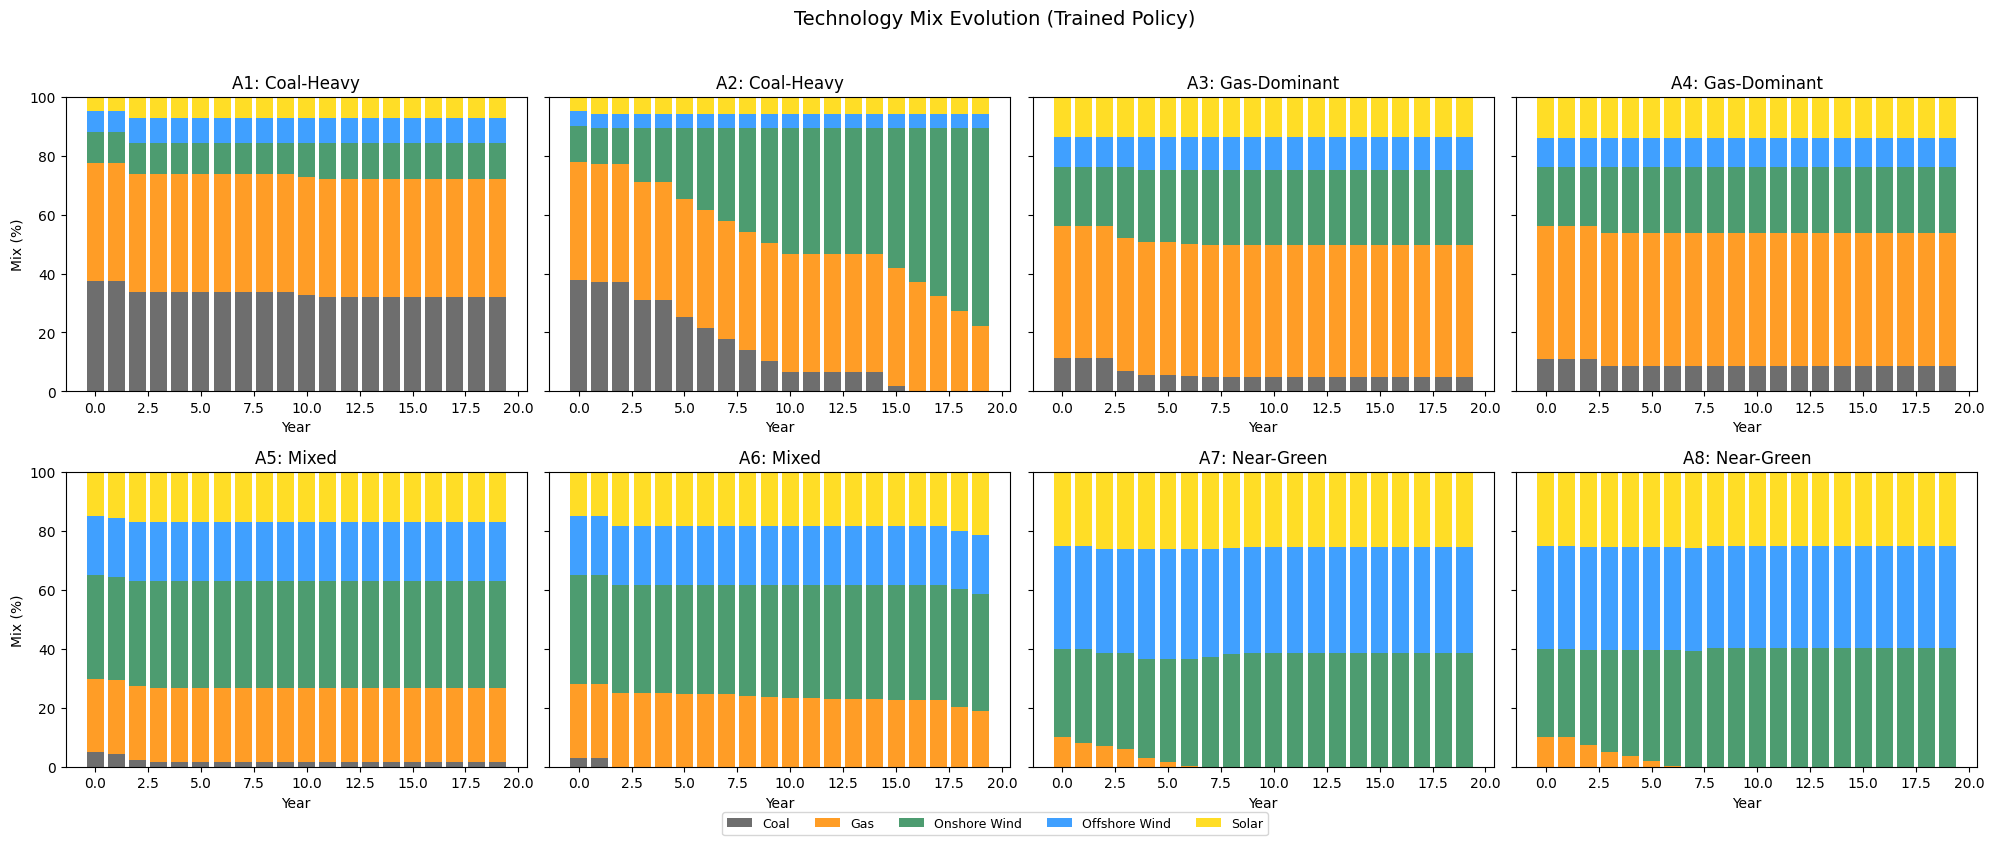

In [17]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# Dynamic archetype labels (2 of each for 8 agents)
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
archetypes = []
for arch in _base_archetypes:
    count = 0
    for mix in config['companies']['initial_mix']:
        # Match archetype by green fraction
        green = sum(mix[j] for j, g in enumerate(config['technologies']['is_green']) if g)
        if arch == 'Coal-Heavy' and green < 0.25:
            count += 1
        elif arch == 'Gas-Dominant' and 0.25 <= green < 0.55:
            count += 1
        elif arch == 'Mixed' and 0.55 <= green < 0.85:
            count += 1
        elif arch == 'Near-Green' and green >= 0.85:
            count += 1
# Simpler: just assign based on position
archetypes = []
n_per = n_agents // 4
for arch in _base_archetypes:
    for k in range(max(1, n_per)):
        archetypes.append(arch)
# Pad if needed
while len(archetypes) < n_agents:
    archetypes.append(f'Agent {len(archetypes)+1}')

ncols = min(4, n_agents)
nrows = (n_agents + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

for i in range(n_agents):
    ax = axes[i]
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)

# Hide unused axes
for j in range(n_agents, len(axes)):
    axes[j].set_visible(False)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [18]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [17]:
# # Full training (uncomment to run)
from scripts.train import train_one_seed

full_config = config.copy()
full_config['simulation'] = dict(config['simulation'])
full_config['simulation']['n_episodes'] = 15000
full_config['logging'] = dict(config['logging'])
full_config['logging']['log_interval'] = 97
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)


Training — seed 42, 8 agents, PPO, two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward
P1-P8 + structural improvements active

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    : Mean emissions (Mt)
  AvgAlloc    : Mean allocation (Mt)
  SfYrs       : Shortfall years
  AvgBi

RuntimeError: [BROKEN – CEILING BID] A3: avg bid >=99% of price_max (500 €/t) for 20 consecutive episodes (ep 1724). Policy collapsed to price ceiling. Aborting.